In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score


In [52]:
data = pd.read_csv('/content/housing.csv')

In [53]:
print(data)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785           616.0   

       population  households  median_income ocean_

In [54]:
print(data.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


In [55]:
import math
median_bedrooms = math.floor(data.total_bedrooms.median())
data.total_bedrooms.fillna(median_bedrooms,inplace=True)
print(data.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64


/tmp/ipykernel_6174/4166441161.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.total_bedrooms.fillna(median_bedrooms,inplace=True)


In [56]:

X = data.drop('median_house_value',axis=1)
Y = data['median_house_value']

In [57]:
# Perform one-hot encoding on 'ocean_proximity'
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

In [58]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [59]:
# Now apply the StandardScaler to the one-hot encoded X
Scaler = StandardScaler()
x_scaled = Scaler.fit_transform(X)

In [60]:
model_instances = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree Regression': DecisionTreeRegressor()
}

# Loop through each model and fit it with the scaled features and target variable
for name, model_obj in model_instances.items():
    print(f"Fitting {name}...")
    model_obj.fit(x_scaled, Y)
    print(f"{name} fitted successfully.")


Fitting Linear Regression...
Linear Regression fitted successfully.
Fitting Ridge Regression...
Ridge Regression fitted successfully.
Fitting Decision Tree Regression...
Decision Tree Regression fitted successfully.


In [61]:
import math
rmse = math.sqrt(mean_squared_error(Y,model_instances['Linear Regression'].predict(x_scaled)))
print(f"RMSE for Linear Regression: {rmse}")
r2 = r2_score(Y,model_instances['Linear Regression'].predict(x_scaled))
print(f"R2 Score for Linear Regression: {r2}")


RMSE for Linear Regression: 68709.3255776217
R2 Score for Linear Regression: 0.6454530166046621


In [62]:
result_data = pd.DataFrame(columns=['Model', 'RMSE', 'R2 Score'])
result_data

,Model,RMSE,R2 Score


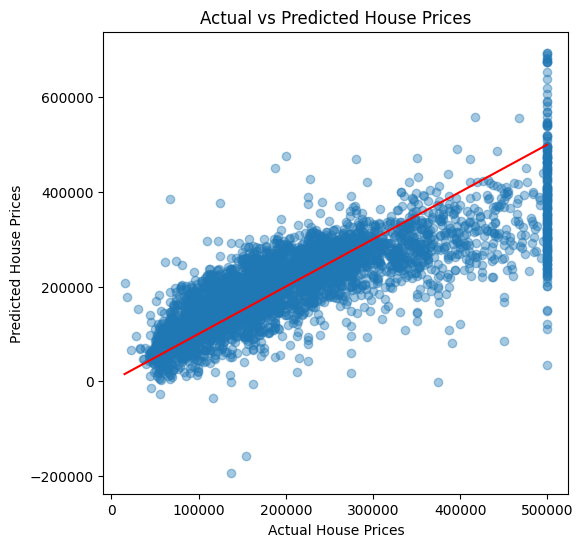

In [63]:
best_model = LinearRegression()

best_model.fit(X_train, Y_train)

Y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(Y_test, Y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.show()